In [2]:
import numpy as np
import scipy
import sys
import os

import pandas as pd

tokenlab_path=os.path.abspath("").replace('projects','src')
sys.path.insert(0,tokenlab_path)


from TokenLab.simulationcomponents import *
from TokenLab.simulationcomponents.usergrowthclasses import *
from TokenLab.simulationcomponents.transactionclasses import *
from TokenLab.simulationcomponents.tokeneconomyclasses import *
from TokenLab.simulationcomponents.transactionclasses import *
from TokenLab.simulationcomponents.agentpoolclasses import *
from TokenLab.simulationcomponents.pricingclasses import *
from TokenLab.simulationcomponents.addons import AddOn_RandomNoise, AddOn_RandomNoiseProportional
from TokenLab.utils.helpers import *
from matplotlib import pyplot as plt

ITERATIONS=12*5
HOLDING_TIME=1
SUPPLY=10**8
INITIAL_PRICE=0.01

In [3]:
random_noise=AddOn_RandomNoiseProportional(std_param=5)

lr=lambda start,stop,num : logistic_saturated_space(start=start,stop=stop,num=num,steepness=4,takeoff=3)

users=UserGrowth_Spaced(initial_users=100000,max_users=750000,num_steps=60,
                        space_function=lr
                        ,noise_addon=random_noise)


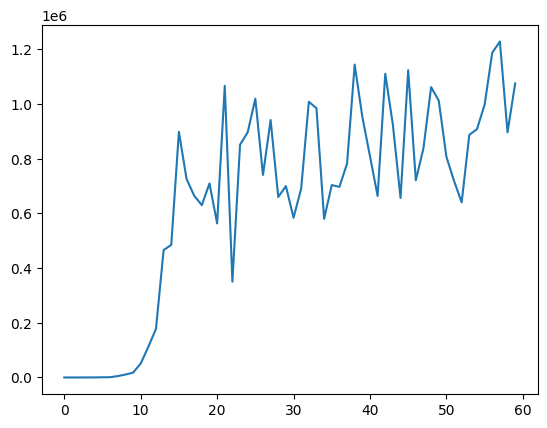

In [4]:
plt.plot(users.get_users_store())

In [8]:
transactions=TransactionManagement_Stochastic(value_distribution=scipy.stats.halfnorm,
                                             value_dist_parameters={'loc':10,'scale':75})

(array([1412., 1202.,  977.,  652.,  392.,  214.,   95.,   39.,   15.,
           2.]),
 array([ 10.02210216,  45.96279946,  81.90349676, 117.84419406,
        153.78489136, 189.72558865, 225.66628595, 261.60698325,
        297.54768055, 333.48837785, 369.42907514]),
 <BarContainer object of 10 artists>)

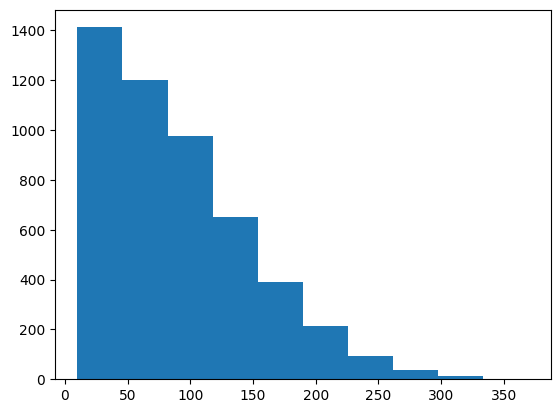

In [13]:
samples=scipy.stats.halfnorm.rvs(loc=10,scale=100,size=5000)
plt.hist(samples)

In [14]:
np.mean(samples)

89.75750315152078

In [10]:
locs=generate_distribution_param_from_sequence(param_name='loc',start=0,stop=9,num=18)
scales=generate_distribution_param_from_sequence(param_name='scale',start=0,stop=2,num=18)
params=merge_param_dists(locs,scales)

In [11]:
holding_time=HoldingTime_Stochastic(holding_time_params=params)

100%|█████████████████████████████████████████| 100/100 [00:05<00:00, 18.20it/s]


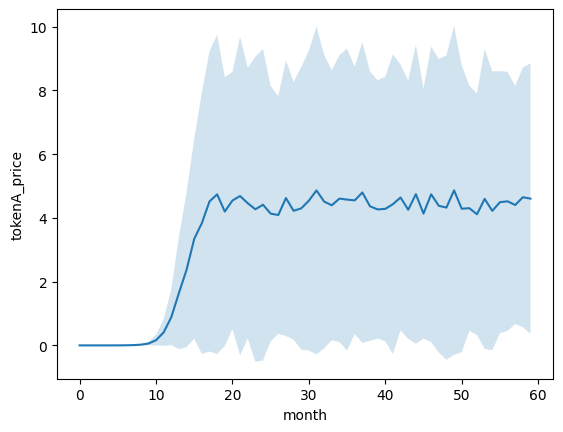

(<matplotlib.collections.PolyCollection at 0x7fc3102f7af0>,
     tokenA_price_mean            sd  month
 0        4.722381e-07  2.059392e-07      0
 1        7.330238e-06  3.704868e-06      1
 2        3.059942e-05  1.710438e-05      2
 3        1.116948e-04  5.626006e-05      3
 4        3.520461e-04  1.751359e-04      4
 5        1.159197e-03  6.614978e-04      5
 6        3.020093e-03  1.520140e-03      6
 7        8.574883e-03  4.725977e-03      7
 8        2.285538e-02  1.158852e-02      8
 9        5.745184e-02  2.819015e-02      9
 10       1.626714e-01  8.517968e-02     10
 11       4.079104e-01  2.145766e-01     11
 12       8.859185e-01  4.476274e-01     12
 13       1.645957e+00  9.017227e-01     13
 14       2.374569e+00  1.239200e+00     14
 15       3.343215e+00  1.597298e+00     15
 16       3.837769e+00  2.094091e+00     16
 17       4.517315e+00  2.403339e+00     17
 18       4.738851e+00  2.556412e+00     18
 19       4.199471e+00  2.151289e+00     19
 20       4.5462

In [8]:


ap_fiat=AgentPool_Basic(users_controller=users,transactions_controller=transactions,currency='$')


te=TokenEconomy_Basic(holding_time=holding_time,supply=SUPPLY,token='tokenA',
                      initial_price=INITIAL_PRICE,burn_token=True)
te.add_agent_pools([ap_fiat])

meta=TokenMetaSimulator(te)
meta.execute(iterations=ITERATIONS,repetitions=100)
reps=meta.get_data()

meta.get_timeseries('tokenA_price')

In [11]:
dat=meta.get_data()

In [16]:
dat[dat.iteration_time==30].tokenA_price.mean()

4.540477170638733